# Run Simulation - Provincial Canada

This notebook covers the full workflow end-to-end:
1. **Build the data pickle**: read raw ICIO, WIOD-SEA, HFCS, and supporting input files; calibrate initial conditions for all 10 provinces; and save to `output/`.
2. **Run the simulation**: load the pickle and step the ABM forward with TFP and technical-coefficient growth enabled.
3. **Plot results**: produce per-province GDP and industry production charts.

## What this model does

The model simulates a multi-sector economy in which firms, households, banks, and government entities interact over discrete timesteps. In this demo notebook, `time_unit = 3`, so each timestep is 3 months. Each province is treated as a separate economy with its own firms, households, banks, and government entity, calibrated from a 2014 provincial input-output table. The current provincial table has 43 industry sectors.

**Productivity growth is enabled.** Firms invest a fraction of available cash into two kinds of improvement each timestep:
- **TFP growth** (`SimpleTFPGrowth`): raises total factor productivity so each unit of input produces more output over time.
- **Technical coefficient growth** (`SimpleTechnicalGrowth`): gradually reduces input requirements per unit of output.



## How this differs from the scenario-comparison notebook

This notebook is the basic smoke-test and handoff workflow: it creates one calibrated provincial data pickle, runs one simulation, saves one HDF5 results file, and produces a few standard plots. The companion `Sample_macroabm-CANADA_run_time_iteration.ipynb` is for comparing multiple scenario configurations and averaging repeated trials.

## Directory structure

```text
repo-root/
  raw_data/                         # external raw data folder supplied by the user
    icio/
    wiod_sea/
    hfcs/
    ...
  output/                           # created automatically by this notebook
    data_provincial_model.pkl       # PKL_PATH, written by Section 4 and read by Section 5
    results_provinces_wTFP.h5
    *.png
  macro_data/
  macromodel/
  Sample_macroabm-Canada_provincial_run.ipynb
```

## How to run

Run the cells top to bottom, in order. Section 4 (Create data pickle) takes several minutes and only needs to run once; it is skipped automatically if the pickle already exists. If you change `time_unit`, raw-data inputs, or the IO table, delete/regenerate the pickle before rerunning the simulation.


## 1 — Autoreload

In [2]:
%load_ext autoreload
%autoreload all

## 2 — Paths

- `INPUT_PATH` — point it to raw data directory folder, containing the OECD ICIO tables, WIOD socioeconomic accounts, HFCS survey files, and other required inputs.
- `PKL_PATH` — where the calibrated `DataWrapper` pickle is saved (`output/data_provincial.pkl`). The `output/` directory is created automatically.
- `OUTPUT_FILENAME` — name of the HDF5 results file written at the end of the simulation.

In [3]:
from pathlib import Path

# Point this to the raw-data folder that contains icio/, wiod_sea/, hfcs/, exchange_rates/, etc.
# Example: INPUT_PATH = Path(r"/path/to/raw_data")
INPUT_PATH       = Path(r"C:\Users\LSTERN\macroabm-ca\raw_data")
BASE_DIR         = Path.cwd()
OUTPUT_DIRECTORY = BASE_DIR / "output"
OUTPUT_FILENAME  = "results_provinces_wTFP.h5"
PKL_PATH         = OUTPUT_DIRECTORY / "data_provincial_model.pkl"

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(f"Input path : {INPUT_PATH}  exists={INPUT_PATH.exists()}")
print(f"Pickle     : {PKL_PATH}")
print(f"Output     : {OUTPUT_DIRECTORY / OUTPUT_FILENAME}")


Input path : C:\Users\LSTERN\macroabm-ca\raw_data  exists=True
Pickle     : c:\Users\LSTERN\macroabm-ca\scenarios\output\data_provincial_model.pkl
Output     : c:\Users\LSTERN\macroabm-ca\scenarios\output\results_provinces_wTFP.h5


## 3 — Imports

In [4]:
import macro_data
from macro_data import DataWrapper, configuration_utils
from macro_data.configuration.countries import Country as CountryCode
from macro_data.configuration.region import Region
from macromodel.configurations import SimulationConfiguration, CountryConfiguration
from macromodel.simulation import Simulation

## 3 - Data configuration

This section builds the `DataConfiguration` object that tells the model how to read and structure the raw input data for the 10 Canadian provinces.

**Key settings:**

| Setting | Value | Meaning |
|---------|-------|---------|
| `use_disagg_can_2014_reader` / `can_disaggregation` | `True` | Use the Canada-specific IO reader with the current provincial table. |
| `aggregation_structure` | `{CAN: [10 provinces]}` | Replace the single Canada entry with 10 separate provincial economies. |
| `single_firm_per_industry` | `True` | Creates one representative firm per sector in each province. |
| `scale` | `1000` | Number of real-world households represented by each synthetic household; see `CountryDataConfiguration.scale` and `hfcs_synthetic_population.py`. |
| `proxy_country_dict` | `{"CAN": "FRA"}` | Use France as the EU proxy for household finance survey data. |

Each province inherits the same base configuration as the national CAN entry: one representative firm per sector, one bank, and one government entity.


In [5]:
data_config = configuration_utils.default_data_configuration(
    countries=["CAN"],
    aggregate_industries=False,
    proxy_country_dict={"CAN": "FRA"},
    use_disagg_can_2014_reader=True,
)

data_config.year                 = 2014
data_config.time_unit            = 3      # demo setting: 3 months per timestep = quarterly
data_config.can_disaggregation   = True
data_config.aggregate_industries = False
data_config.prune_date           = None
data_config.seed                 = 0

base_config = data_config.country_configs[CountryCode("CAN")]
base_config.single_firm_per_industry  = True
base_config.single_bank               = True
base_config.single_government_entity  = True
base_config.firms_configuration.constructor = "Default"
base_config.scale = 1000              # real-world households represented by each synthetic household

provinces = [
    Region.from_code("CAN_AB", "Alberta"),
    Region.from_code("CAN_BC", "British Columbia"),
    Region.from_code("CAN_MB", "Manitoba"),
    Region.from_code("CAN_NB", "New Brunswick"),
    Region.from_code("CAN_NL", "Newfoundland and Labrador"),
    Region.from_code("CAN_NS", "Nova Scotia"),
    Region.from_code("CAN_ON", "Ontario"),
    Region.from_code("CAN_PE", "Prince Edward Island"),
    Region.from_code("CAN_QC", "Quebec"),
    Region.from_code("CAN_SK", "Saskatchewan"),
]

for province in provinces:
    data_config.country_configs[province] = base_config
    data_config.country_configs[province].eu_proxy_country = CountryCode("FRA")

data_config.aggregation_structure = {CountryCode("CAN"): provinces}

print(f"Provinces       : {[str(p) for p in provinces]}")
print(f"Config entries  : {len(data_config.country_configs)}")
print(f"Time unit       : {data_config.time_unit} months/step")


Provinces       : ['CAN_AB', 'CAN_BC', 'CAN_MB', 'CAN_NB', 'CAN_NL', 'CAN_NS', 'CAN_ON', 'CAN_PE', 'CAN_QC', 'CAN_SK']
Config entries  : 11
Time unit       : 3 months/step


## 4 - Create data pickle

**Only needs to run once.** Reads all raw data files, calibrates initial conditions, and saves to `output/data_provincial_model.pkl`.

`DataWrapper.from_config` performs these steps:
1. Reads the provincial IO table and WIOD socioeconomic accounts.
2. Matches investment matrices to value-added data through the `icio_sea_matching` step.
3. Constructs household wealth distributions from HFCS survey microdata.
4. Builds firm-level initial conditions including wages, capital stocks, inventories, and production targets.

`creator.save(PKL_PATH)` serialises the result. Once this file exists, skip this cell on subsequent runs and proceed directly to Section 5.


In [6]:
import time

if PKL_PATH.exists():
    print(f"Pickle already exists at {PKL_PATH} — skipping data creation.")
else:
    t0 = time.time()
    creator = DataWrapper.from_config(
        configuration=data_config,
        raw_data_path=INPUT_PATH,
        single_hfcs_survey=True,
    )
    creator.save(PKL_PATH)
    print(f"Pickle saved to {PKL_PATH}  ({(time.time() - t0) / 60:.1f} min)")

Pickle already exists at c:\Users\LSTERN\macroabm-ca\scenarios\output\data_provincial_model.pkl — skipping data creation.


## 5 — Load data

Loads the `DataWrapper` saved in Section 4. `DataWrapper.init_from_pickle` is the correct loader when the pickle was written with `creator.save()` (which serialises a dict). If you have a pickle written with `pkl.dump(data_wrapper, f)`, use `pkl.load(f)` instead.

In [7]:
data = DataWrapper.init_from_pickle(PKL_PATH)

n_industries = data.n_industries
industries   = data.industries
print(f"n_industries : {n_industries}")
print(f"industries   : {list(industries)}")

n_industries : 43
industries   : ['A', 'B05a', 'B05b', 'B05c', 'B07', 'B09', 'C10T12', 'C13T15', 'C16', 'C17', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24a', 'C24b', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31T33', 'D', 'E', 'F', 'G', 'H49', 'H50', 'H51', 'H52', 'H53', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R_S']


## 6 - Simulation parameters

This notebook is a short demo with `time_unit = 3`, so each timestep represents 3 months and four timesteps equal one year.

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `TIMESTEPS` | 16 | Number of 3-month timesteps to simulate (4 years) |
| `SEED` | 0 | Random seed for reproducibility |
| `tfp_base_growth_rate` | 0.001 | Autonomous TFP growth per timestep, independent of investment |
| `tfp_investment_elasticity` | 0.5 | How strongly TFP responds to investment spending |
| `productivity_growth_investment_effectiveness` | 0.3 | Fraction of TFP investment that actually improves productivity |
| `technical_coefficients_investment_effectiveness` | 0.3 | Fraction of technical investment that reduces input coefficients |
| `diminishing_returns_factor` | 0.1 | Rate at which returns to technical investment diminish |
| `hurdle_rate` | 0.01 | Minimum expected return required before a firm invests in productivity |
| `tfp_investment_share` | 0.5 | Share of productivity budget going to TFP rather than technical coefficients |
| `max_investment_fraction` | 0.2 | Maximum share of a firm's cash that can be spent on productivity investment |

For branch validation and comparison runs, also read `docs/canada_provincial_io_development.md`; those runs may use a different timestep convention and seed.


In [8]:
import random

TIMESTEPS = 16
SEED      = 0

# TFP / investment parameters used for this short demo run.
tfp_base_growth_rate              = 0.001
tfp_investment_elasticity         = 0.5
productivity_growth_investment_effectiveness          = 0.3
technical_coefficients_investment_effectiveness       = 0.3
diminishing_returns_factor                            = 0.1
hurdle_rate                                           = 0.01
investment_effectiveness                              = 0.3
technical_investment_effectiveness                    = 0.3
technical_diminishing_returns                         = 0.1
tfp_investment_share                                  = 0.5
max_investment_fraction                               = 0.2

print(f"Timesteps : {TIMESTEPS}")
print(f"Seed      : {SEED}")
print("Note: this notebook uses a short quarterly demo setup. See docs/canada_provincial_io_development.md for branch validation notes.")


Timesteps : 16
Seed      : 0
Note: this notebook uses a short quarterly demo setup. See docs/canada_provincial_io_development.md for branch validation notes.


In [ ]:
# Taxation policy parameters
use_taxation_policies = True

rate_flat = [(float('inf'), 0.09)]

rate_prog = [
    (50000, 0.10),
    (100000, 0.20),
    (float('inf'), 0.30)
]

## 7 — Build simulation configuration

A `SimulationConfiguration` specifies how agents behave — it is separate from the calibrated data (`DataWrapper`). This lets you change the model's rules (e.g. pricing behaviour, growth mechanisms) without reprocessing raw data.

Each province gets a `CountryConfiguration` built with `n_industry_default`, which sets up one representative firm per industry sector. The `for` loop then attaches the productivity investment configuration to each province's firms block.

**Key design choices in this notebook:**
- No energy substitution bundles — firms use the standard Leontief production function.
- Productivity investment is active for all provinces with the parameters from Section 6.

In [10]:
provinces = [
    Region.from_code("CAN_AB", "Alberta"),
    Region.from_code("CAN_BC", "British Columbia"),
    Region.from_code("CAN_MB", "Manitoba"),
    Region.from_code("CAN_NB", "New Brunswick"),
    Region.from_code("CAN_NL", "Newfoundland and Labrador"),
    Region.from_code("CAN_NS", "Nova Scotia"),
    Region.from_code("CAN_ON", "Ontario"),
    Region.from_code("CAN_PE", "Prince Edward Island"),
    Region.from_code("CAN_QC", "Quebec"),
    Region.from_code("CAN_SK", "Saskatchewan"),
]

config = SimulationConfiguration(
    seed=SEED,
    country_configurations={
        province: CountryConfiguration.n_industry_default(n_industries=n_industries)
        for province in provinces
    },
    t_max=TIMESTEPS,
)

for province in provinces:  
    firms = config.country_configurations[province].firms

    firms.functions.productivity_investment_planner.name = "SimpleProductivityInvestmentPlanner"
    firms.functions.productivity_investment_planner.parameters.update({
        "n_firms":                      n_industries,
        "tfp_investment_share":          tfp_investment_share,
        "max_investment_fraction":       max_investment_fraction,
        "investment_effectiveness":      investment_effectiveness,
        "technical_investment_effectiveness": technical_investment_effectiveness,
        "technical_diminishing_returns": technical_diminishing_returns,
        "hurdle_rate":                   hurdle_rate,
    })

    firms.functions.productivity_growth.name = "SimpleTFPGrowth"
    firms.functions.productivity_growth.parameters = {
        "investment_effectiveness": productivity_growth_investment_effectiveness,
    }
    firms.parameters.tfp_base_growth_rate     = tfp_base_growth_rate
    firms.parameters.tfp_investment_elasticity = tfp_investment_elasticity

    firms.functions.technical_coefficients_growth.name = "SimpleTechnicalGrowth"
    firms.functions.technical_coefficients_growth.parameters = {
        "investment_effectiveness":  technical_coefficients_investment_effectiveness,
        "diminishing_returns_factor": diminishing_returns_factor,
    }

    # Taxation configuration (NOTE: can be set differently for each province)
    config.country_configurations[province].use_taxation_policies = use_taxation_policies
    config.country_configurations[province].rate_flat = rate_flat
    config.country_configurations[province].rate_prog = rate_prog

print("Configuration built.")

Configuration built.


## 8 - Run and save

`Simulation.from_datawrapper` combines the calibrated initial conditions (`DataWrapper`) with the behavioural rules (`SimulationConfiguration`) to create a ready-to-run simulation object.

`model.run()` steps through all `TIMESTEPS` periods. With the demo `time_unit = 3`, each period is 3 months.

`model.save()` writes the full time series to HDF5. The file can be large for long runs; subsequent sections load only what is needed for plotting.


In [12]:
import time

model = Simulation.from_datawrapper(datawrapper=data, simulation_configuration=config)

t0 = time.time()

# initialize non-timeseries variables for use during analysis
ts_time = []
ts_time.append('2014-0')

for t in range(TIMESTEPS):

    # store non-timeseries variables
    ts_time.append(str(model.timestep))

    model.iterate(t)

print(f"Simulation complete in {(time.time() - t0) / 60:.1f} min")

model.save(save_dir=OUTPUT_DIRECTORY, file_name=OUTPUT_FILENAME)
print(f"Results saved to {OUTPUT_DIRECTORY / OUTPUT_FILENAME}")

t: 0, timestep: 2014-1
test equivalence (method vs manual): True
Compare calculations for this timestep:
	total_personal_income_tax (new pipeline): $8,961,759,123.97 at [(inf, 0.15)] rate
	total_personal_income_tax (original pipeline): $5,555,392,059.92 at 0.09 rate
Got here!!
test equivalence (method vs manual): False
Compare calculations for this timestep:
	total_personal_income_tax (new pipeline): $5,878,984,059.48 at [(inf, 0.15)] rate
	total_personal_income_tax (original pipeline): $3,651,073,600.66 at 0.09 rate
Got here!!
test equivalence (method vs manual): False
Compare calculations for this timestep:
	total_personal_income_tax (new pipeline): $1,544,436,065.41 at [(inf, 0.15)] rate
	total_personal_income_tax (original pipeline): $951,304,060.30 at 0.09 rate
Got here!!
test equivalence (method vs manual): True
Compare calculations for this timestep:
	total_personal_income_tax (new pipeline): $807,907,243.15 at [(inf, 0.15)] rate
	total_personal_income_tax (original pipeline): $

C:\Users\LSTERN\macroabm-ca\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
C:\Users\LSTERN\macroabm-ca\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
C:\Users\LSTERN\macroabm-ca\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
C:\Users\LSTERN\macroabm-ca\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
C:\Users\LSTERN\macroabm-ca\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in 

KeyboardInterrupt: 

In [ ]:
### OLD VERSION
# import time

# model = Simulation.from_datawrapper(datawrapper=data, simulation_configuration=config)

# t0 = time.time()
# model.run()
# print(f"Simulation complete in {(time.time() - t0) / 60:.1f} min")

# model.save(save_dir=OUTPUT_DIRECTORY, file_name=OUTPUT_FILENAME)
# print(f"Results saved to {OUTPUT_DIRECTORY / OUTPUT_FILENAME}")

## 9 - Results utilities

Helper functions for loading and inspecting the HDF5 output file. The HDF5 file is organised as a hierarchy: `<province>/<agent_type>/<variable>` (for example, `CAN_ON/firms/production`). The utilities below let you:

- `get_tree`: build a dictionary representation of the file structure.
- `list_dataset_paths`: list every dataset path in the file.
- `load_dataset`: load a specific dataset as a NumPy array.
- `compute_real_gdp`: compute real GDP by deflating nominal GDP with the CPI.
- `get_column_labels`: map industry indices to human-readable names if `can_industries_wnames.csv` is available in the raw-data folder.
- `sum_regions`: aggregate a variable across all provinces.

Running this cell also prints the top-level structure of the results file so you can see what is available.


In [20]:
from typing import Any, Dict, Iterable, List, Optional

import h5py
import numpy as np
import pandas as pd

INDUSTRY_NAMES_CSV = INPUT_PATH / "can_industries_wnames.csv"

TreeNode = Dict[str, Any]


def load_industry_mapping() -> Dict[int, str]:
    if not INDUSTRY_NAMES_CSV.exists():
        return {}
    df = pd.read_csv(INDUSTRY_NAMES_CSV)
    return dict(zip(df["Firm_ID"], df["Industry_Name"]))


def _build_tree(group: h5py.Group) -> TreeNode:
    tree: TreeNode = {}
    for key in group.keys():
        obj = group[key]
        if isinstance(obj, h5py.Dataset):
            tree[key] = {"type": "dataset"}
        else:
            tree[key] = {"type": "group", "children": _build_tree(obj)}
    return tree


def get_tree(file_path) -> TreeNode:
    with h5py.File(file_path, "r") as f:
        return _build_tree(f)


def list_dataset_paths(tree: TreeNode, prefix: str = "") -> List[str]:
    paths: List[str] = []
    for key in sorted(tree.keys()):
        entry = tree[key]
        current_path = f"{prefix}/{key}" if prefix else key
        if entry["type"] == "dataset":
            paths.append(current_path)
        else:
            paths.extend(list_dataset_paths(entry["children"], current_path))
    return paths


def load_dataset(file_path, dataset_path: str) -> np.ndarray:
    with h5py.File(file_path, "r") as f:
        return f[dataset_path][()]


def compute_real_gdp(file_path, province: str) -> Optional[np.ndarray]:
    gdp_path = f"{province}/economy/gdp_output"
    cpi_path = f"{province}/economy/cpi"
    with h5py.File(file_path, "r") as f:
        if gdp_path not in f or cpi_path not in f:
            return None
        gdp = f[gdp_path][()].astype(float)
        cpi = f[cpi_path][()].astype(float)
    return np.divide(gdp, cpi, out=np.full_like(gdp, np.nan), where=cpi != 0)


def get_column_labels(file_path, dataset_path: str, industry_mapping: Optional[Dict[int, str]] = None) -> Optional[List[str]]:
    columns_path = f"{dataset_path}_columns"
    with h5py.File(file_path, "r") as f:
        if columns_path not in f:
            return None
        cols = np.asarray(f[columns_path][()])
    if cols.ndim == 1:
        if industry_mapping:
            return [industry_mapping.get(int(i), str(int(i))) for i in cols]
        return [str(int(i)) for i in cols]
    if cols.ndim == 2 and cols.shape[1] == 2:
        if industry_mapping:
            return [f"[{industry_mapping.get(int(a), str(int(a)))}, {industry_mapping.get(int(b), str(int(b)))}]" for a, b in cols]
        return [f"[{int(a)}, {int(b)}]" for a, b in cols]
    return [str(x) for x in cols.flatten()]


def merge_trees(trees: Iterable[TreeNode]) -> TreeNode:
    merged: TreeNode = {}
    for tree in trees:
        for key, entry in tree.items():
            if key not in merged:
                merged[key] = entry
                continue
            if merged[key]["type"] == "group" or entry["type"] == "group":
                merged[key] = {
                    "type": "group",
                    "children": merge_trees([
                        merged[key].get("children", {}),
                        entry.get("children", {}),
                    ]),
                }
    return merged


def add_can_region(tree: TreeNode) -> List[str]:
    province_keys = [k for k, v in tree.items() if v["type"] == "group" and k.startswith("CAN_")]
    if province_keys:
        can_children = merge_trees([tree[p]["children"] for p in province_keys])
        tree["CAN"] = {"type": "group", "children": can_children}
    return province_keys


def sum_regions(file_path, province_keys: List[str], tail_path: str) -> Optional[np.ndarray]:
    total: Optional[np.ndarray] = None
    with h5py.File(file_path, "r") as f:
        for province in province_keys:
            full = f"{province}/{tail_path}"
            if full not in f:
                continue
            data = f[full][()].astype(float)
            total = data.copy() if total is None else total + data
    return total


industry_mapping = load_industry_mapping()
print(f"Industry mapping loaded: {len(industry_mapping)} industries")

tree = get_tree(OUTPUT_DIRECTORY / OUTPUT_FILENAME)
regions = add_can_region(tree)
all_paths = list_dataset_paths(tree)

print(f"\nProvinces found : {regions}")
print(f"Total datasets  : {len(all_paths)}")
print("\nTop-level keys:")
for k, v in sorted(tree.items()):
    print(f"  {k}  [{v['type']}]")



Industry mapping loaded: 50 industries

Provinces found : ['CAN_AB', 'CAN_BC', 'CAN_MB', 'CAN_NB', 'CAN_NL', 'CAN_NS', 'CAN_ON', 'CAN_PE', 'CAN_QC', 'CAN_SK']
Total datasets  : 8549

Top-level keys:
  CAN  [group]
  CAN_AB  [group]
  CAN_BC  [group]
  CAN_MB  [group]
  CAN_NB  [group]
  CAN_NL  [group]
  CAN_NS  [group]
  CAN_ON  [group]
  CAN_PE  [group]
  CAN_QC  [group]
  CAN_SK  [group]
  GM  [group]
  ROW  [group]


## 10 - Plot results

Three standard plots are produced and saved to `output/`:
1. Nominal GDP by province.
2. Real GDP by province, computed as GDP divided by CPI where both series are available.
3. Production by industry, summed across provinces, showing the top 10 industries by average output.

PNG files are written to `output/` alongside the HDF5 file.

The first two plots are intended as quick sanity checks: look for explosive paths, sudden breaks, or province trajectories that move implausibly relative to the others. The production plot is a compact way to see whether the largest sectors dominate the run as expected.


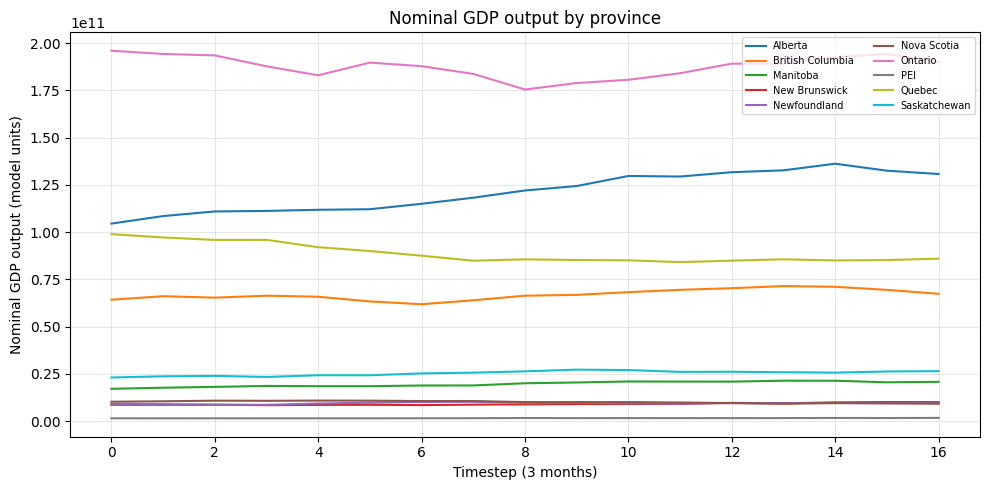

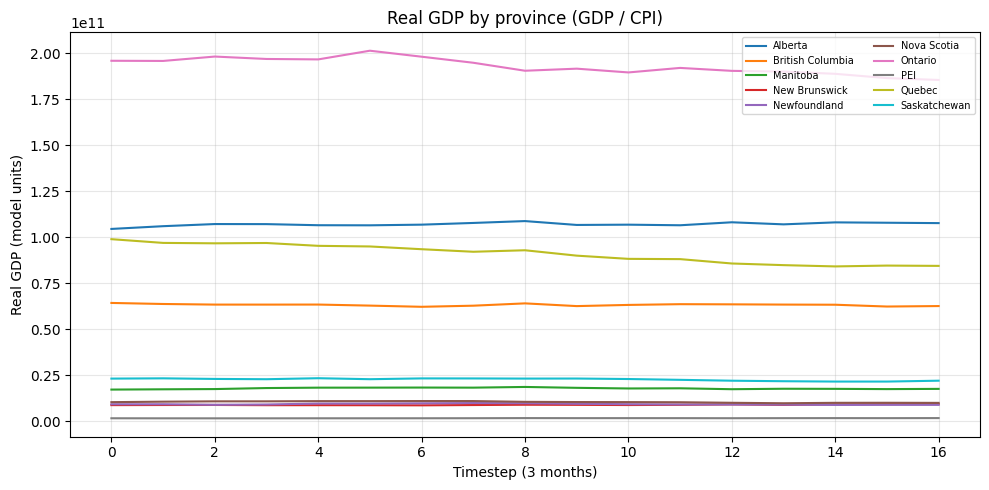

In [21]:
import matplotlib.pyplot as plt

H5_FILE = OUTPUT_DIRECTORY / OUTPUT_FILENAME
PROVINCE_LABELS = {
    "CAN_AB": "Alberta",      "CAN_BC": "British Columbia", "CAN_MB": "Manitoba",
    "CAN_NB": "New Brunswick","CAN_NL": "Newfoundland",     "CAN_NS": "Nova Scotia",
    "CAN_ON": "Ontario",      "CAN_PE": "PEI",              "CAN_QC": "Quebec",
    "CAN_SK": "Saskatchewan",
}

# GDP by province
fig, ax = plt.subplots(figsize=(10, 5))
with h5py.File(H5_FILE, "r") as f:
    for region in regions:
        path = f"{region}/economy/gdp_output"
        if path in f:
            gdp = f[path][()].astype(float)
            ax.plot(gdp, label=PROVINCE_LABELS.get(region, region))
ax.set_title("Nominal GDP output by province")
ax.set_xlabel("Timestep (3 months)")
ax.set_ylabel("Nominal GDP output (model units)")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / "gdp_by_province.png", dpi=120)
plt.show()

# Real GDP by province
fig, ax = plt.subplots(figsize=(10, 5))
for region in regions:
    real_gdp = compute_real_gdp(H5_FILE, region)
    if real_gdp is not None:
        ax.plot(real_gdp, label=PROVINCE_LABELS.get(region, region))
ax.set_title("Real GDP by province (GDP / CPI)")
ax.set_xlabel("Timestep (3 months)")
ax.set_ylabel("Real GDP (model units)")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / "real_gdp_by_province.png", dpi=120)
plt.show()



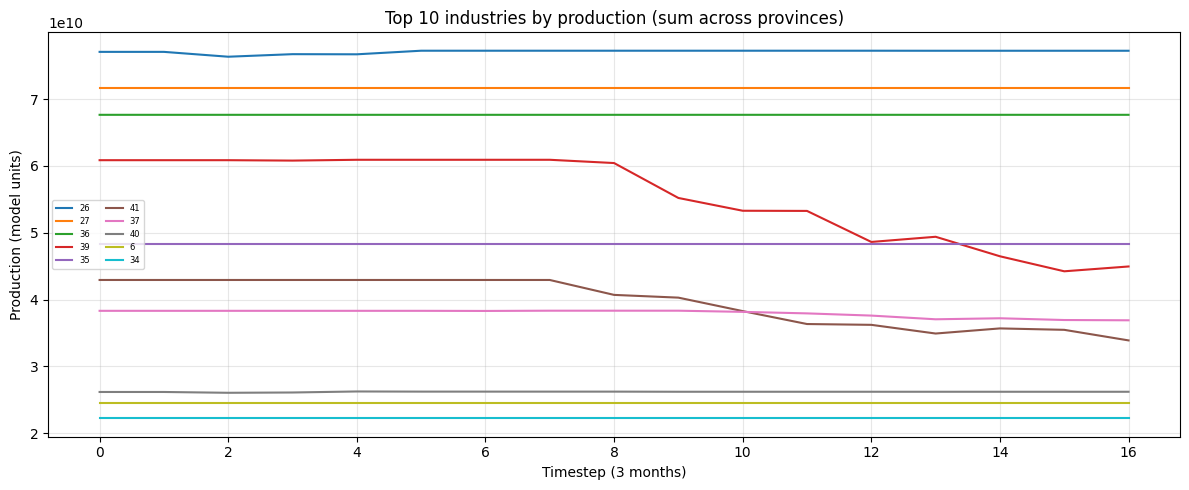

All dataset paths in H5 file:
  CAN/CM/total_newly_loans_granted_firms_long_term
  CAN/CM/total_newly_loans_granted_firms_short_term
  CAN/CM/total_newly_loans_granted_households_consumption
  CAN/CM/total_newly_loans_granted_mortgages
  CAN/CM/total_outstanding_loans_granted_firms_long_term
  CAN/CM/total_outstanding_loans_granted_firms_short_term
  CAN/CM/total_outstanding_loans_granted_households_consumption
  CAN/CM/total_outstanding_loans_granted_mortgages
  CAN/banks/average_interest_rate_on_firm_deposits
  CAN/banks/average_interest_rate_on_household_deposits
  CAN/banks/average_interest_rates_on_household_consumption_loans
  CAN/banks/average_interest_rates_on_long_term_firm_loans
  CAN/banks/average_interest_rates_on_mortgages
  CAN/banks/average_interest_rates_on_short_term_firm_loans
  CAN/banks/average_overdraft_rate_on_firm_deposits
  CAN/banks/average_overdraft_rate_on_household_deposits
  CAN/banks/consumption_loans_to_households
  CAN/banks/deposits
  CAN/banks/deposits

In [22]:
# Production by industry, summed across provinces
production_total = sum_regions(H5_FILE, regions, "firms/production")

if production_total is not None:
    labels = get_column_labels(H5_FILE, f"{regions[0]}/firms/production", industry_mapping)
    n_show = min(10, production_total.shape[1])
    mean_prod = production_total.mean(axis=0)
    top_idx = np.argsort(mean_prod)[::-1][:n_show]

    fig, ax = plt.subplots(figsize=(12, 5))
    for i in top_idx:
        name = labels[i] if labels else str(i)
        ax.plot(production_total[:, i], label=name)
    ax.set_title(f"Top {n_show} industries by production (sum across provinces)")
    ax.set_xlabel("Timestep (3 months)")
    ax.set_ylabel("Production (model units)")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIRECTORY / "production_top_industries.png", dpi=120)
    plt.show()

print("All dataset paths in H5 file:")
for p in all_paths:
    print(f"  {p}")



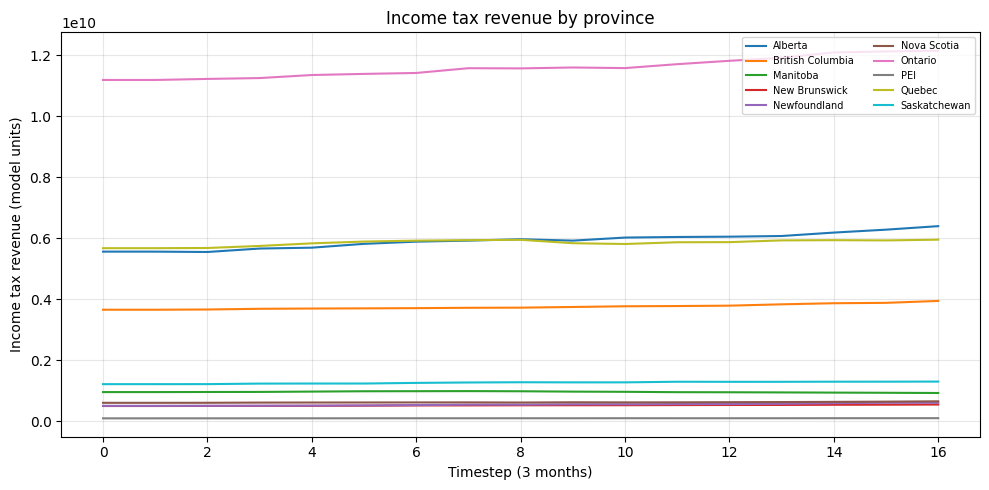

In [23]:
### plot original income tax

import matplotlib.pyplot as plt

H5_FILE = OUTPUT_DIRECTORY / OUTPUT_FILENAME
PROVINCE_LABELS = {
    "CAN_AB": "Alberta",      "CAN_BC": "British Columbia", "CAN_MB": "Manitoba",
    "CAN_NB": "New Brunswick","CAN_NL": "Newfoundland",     "CAN_NS": "Nova Scotia",
    "CAN_ON": "Ontario",      "CAN_PE": "PEI",              "CAN_QC": "Quebec",
    "CAN_SK": "Saskatchewan",
}

# GDP by province
fig, ax = plt.subplots(figsize=(10, 5))
with h5py.File(H5_FILE, "r") as f:
    for region in regions:
        path = f"{region}/central_government/taxes_income"
        if path in f:
            gdp = f[path][()].astype(float)
            ax.plot(gdp, label=PROVINCE_LABELS.get(region, region))
ax.set_title("Income tax revenue by province")
ax.set_xlabel("Timestep (3 months)")
ax.set_ylabel("Income tax revenue (model units)")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / "taxes_income_by_province.png", dpi=120)
plt.show()



C:\Users\LSTERN\AppData\Local\Temp\ipykernel_7120\276750433.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, ncol=2)


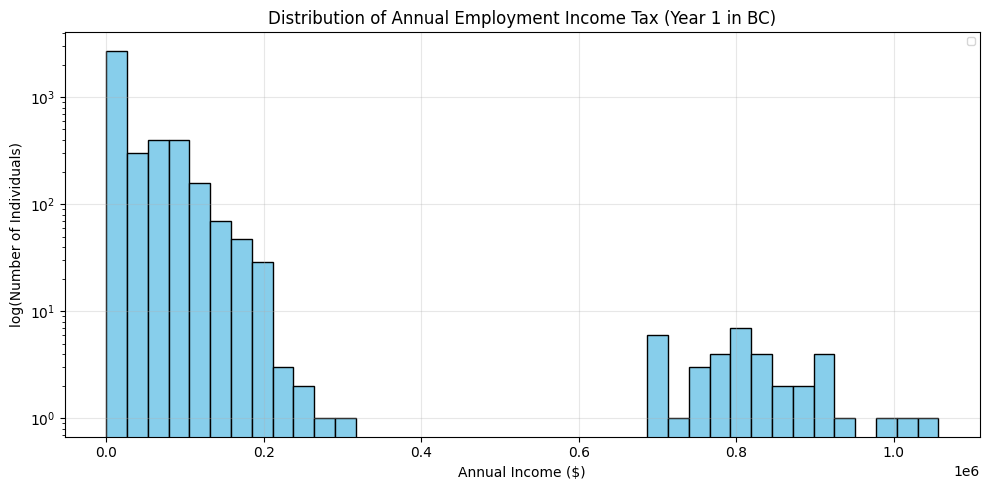

mean: $37,320.71
median: $0.00
min: $0.00
max: $1,056,470.50


In [24]:
### plot employee_income histogram

import matplotlib.pyplot as plt

H5_FILE = OUTPUT_DIRECTORY / OUTPUT_FILENAME
PROVINCE_LABELS = {
    "CAN_AB": "Alberta",      "CAN_BC": "British Columbia", "CAN_MB": "Manitoba",
    "CAN_NB": "New Brunswick","CAN_NL": "Newfoundland",     "CAN_NS": "Nova Scotia",
    "CAN_ON": "Ontario",      "CAN_PE": "PEI",              "CAN_QC": "Quebec",
    "CAN_SK": "Saskatchewan",
}

# year to plot
year = 0

# employee_income for BC
fig, ax = plt.subplots(figsize=(10, 5))
with h5py.File(H5_FILE, "r") as f:
    # for region in regions:
    region = "CAN_BC"
    path = f"{region}/individuals/employee_income"
    if path in f:
        income = f[path][()].astype(float)
        annual_income = (
            income[0 + year] + 
            income[1 + year] + 
            income[2 + year] + 
            income[3 + year])/1000
        ax.hist(annual_income, bins=40, color='skyblue', edgecolor='black')
ax.set_title(f"Distribution of Annual Employment Income Tax (Year 1 in BC)") 
ax.set_xlabel("Annual Income ($)")
ax.set_ylabel("log(Number of Individuals)")

# attempt to increase frequency of x axis
# x_min = 0
# x_max = 1.1e6
# x_inc = x_max / 20
# ax.set_xlim(left=x_min, right=x_max)
# ax.set_xticks(np.arange(0, x_max, x_inc))

ax.set_yscale('log')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(OUTPUT_DIRECTORY / "histogram_employee_income", dpi=120)
plt.show()

# Metrics
print(f"mean: ${np.mean(annual_income):,.2f}")
print(f"median: ${np.median(annual_income):,.2f}")      # why is median 0?
print(f"min: ${np.min(annual_income):,.2f}")
print(f"max: ${np.max(annual_income):,.2f}")


In [44]:
# ### plot SINGLE taxable income histograms

# import matplotlib.pyplot as plt

# H5_FILE = OUTPUT_DIRECTORY / OUTPUT_FILENAME
# PROVINCE_LABELS = {
#     "CAN_AB": "Alberta",      "CAN_BC": "British Columbia", "CAN_MB": "Manitoba",
#     "CAN_NB": "New Brunswick","CAN_NL": "Newfoundland",     "CAN_NS": "Nova Scotia",
#     "CAN_ON": "Ontario",      "CAN_PE": "PEI",              "CAN_QC": "Quebec",
#     "CAN_SK": "Saskatchewan",
# }

# # to_plot = "taxable_income"
# # to_plot = "taxable_income_employment"
# # to_plot = "taxable_income_unemployment"
# to_plot = "taxable_income_rental"

# # year to plot
# year = 1            # TODO: build timestep timeseries for plotting

# # employee_income for BC
# fig, ax = plt.subplots(figsize=(10, 5))
# with h5py.File(H5_FILE, "r") as f:
#     # for region in regions:
#     region = "CAN_BC"
#     path = f"{region}/individuals/{to_plot}"
#     if path in f:
#         income = f[path][()].astype(float)
#         annual_income = (
#             income[0 + year] + 
#             income[1 + year] + 
#             income[2 + year] + 
#             income[3 + year])/1000
#         ax.hist(annual_income, bins=40, color='skyblue', edgecolor='black')
# ax.set_title(f"Distribution of Annual {to_plot} (Year {year} in BC)") 
# ax.set_xlabel("Annual Income ($)")
# ax.set_ylabel("log(Number of Individuals)")

# # attempt to increase frequency of x axis
# # x_min = 0
# # x_max = 1.1e6
# # x_inc = x_max / 20
# # ax.set_xlim(left=x_min, right=x_max)
# # ax.set_xticks(np.arange(0, x_max, x_inc))

# ax.set_yscale('log')
# ax.legend(fontsize=7, ncol=2)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# # plt.savefig(OUTPUT_DIRECTORY / "histogram_employee_income", dpi=120)
# plt.show()

# # Metrics
# print(f"mean: ${np.mean(annual_income):,.2f}")
# print(f"median: ${np.median(annual_income):,.2f}")      # why is median 0?
# print(f"min: ${np.min(annual_income):,.2f}")
# print(f",ax: ${np.max(annual_income):,.2f}")


taxable_income
taxable_income_employment
taxable_income_unemployment
taxable_income_rental


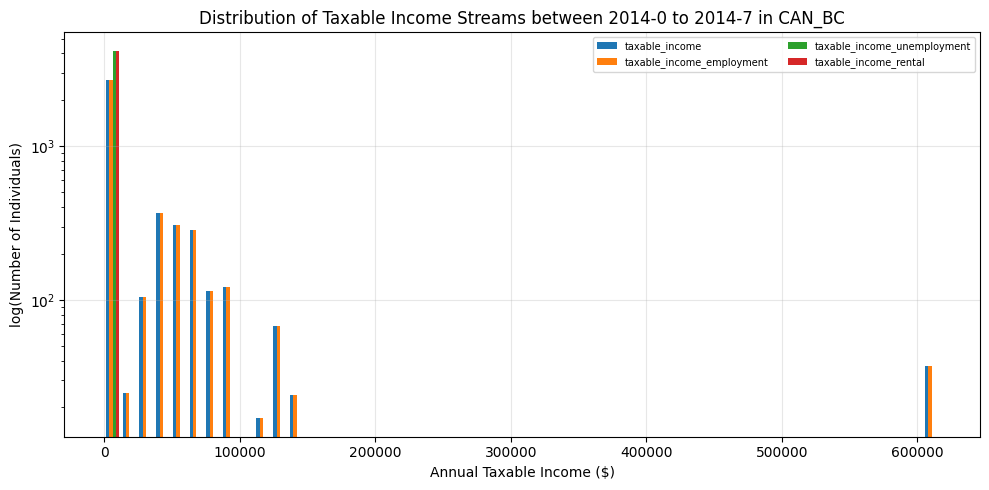

mean: $28,258.66
median: $674.96
min: $0.00
max: $616,747.64


In [ ]:
### plot ALL taxable income histograms

import matplotlib.pyplot as plt
import datetime

H5_FILE = OUTPUT_DIRECTORY / OUTPUT_FILENAME
PROVINCE_LABELS = {
    "CAN_AB": "Alberta",      "CAN_BC": "British Columbia", "CAN_MB": "Manitoba",
    "CAN_NB": "New Brunswick","CAN_NL": "Newfoundland",     "CAN_NS": "Nova Scotia",
    "CAN_ON": "Ontario",      "CAN_PE": "PEI",              "CAN_QC": "Quebec",
    "CAN_SK": "Saskatchewan",
}

# year to plot
year = 0

# variables to plot
variable_str = []
variable_str.append("taxable_income")
variable_str.append("taxable_income_employment")
variable_str.append("taxable_income_unemployment")
variable_str.append("taxable_income_rental")

num_variables = len(variable_str)

for i in range(num_variables):
    print(variable_str[i])

path_str = []
annual_data = []

fig, ax = plt.subplots(figsize=(10, 5))
with h5py.File(H5_FILE, "r") as f:
    # for region in regions:
    region = "CAN_BC"
    agent = "/individuals/"
    for i in range(num_variables):
        path_str = region + agent + variable_str[i]

        if path_str in f:
            data = f[path_str][()].astype(float)
            annual_data.append((data[0 + year] + data[1 + year] + data[2 + year] + data[3 + year])/1000)

    ax.hist([annual_data[0], annual_data[1], annual_data[2], annual_data[3]], 
            bins=50,
            # color=['blue', 'red', 'green', 'orange'], 
            label=[variable_str[0], variable_str[1], variable_str[2], variable_str[3]]
            )
    
ax.set_title(f"Distribution of Taxable Income Streams between {ts_time[year]} to {ts_time[3 + year]} in {region}") 
ax.set_xlabel("Annual Taxable Income ($)")
ax.set_ylabel("log(Number of Individuals)")

ax.set_yscale('log')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / f"taxable_income_histogram_{datetime.date.today()}", dpi=120)
plt.show()

# Metrics
print(f"mean: ${np.mean(annual_data[0]):,.2f}")
print(f"median: ${np.median(annual_data[0]):,.2f}")      # why is median 0?
print(f"min: ${np.min(annual_data[0]):,.2f}")
print(f"max: ${np.max(annual_data[0]):,.2f}")


taxable_income
taxable_income_employment
taxable_income_unemployment
taxable_income_rental


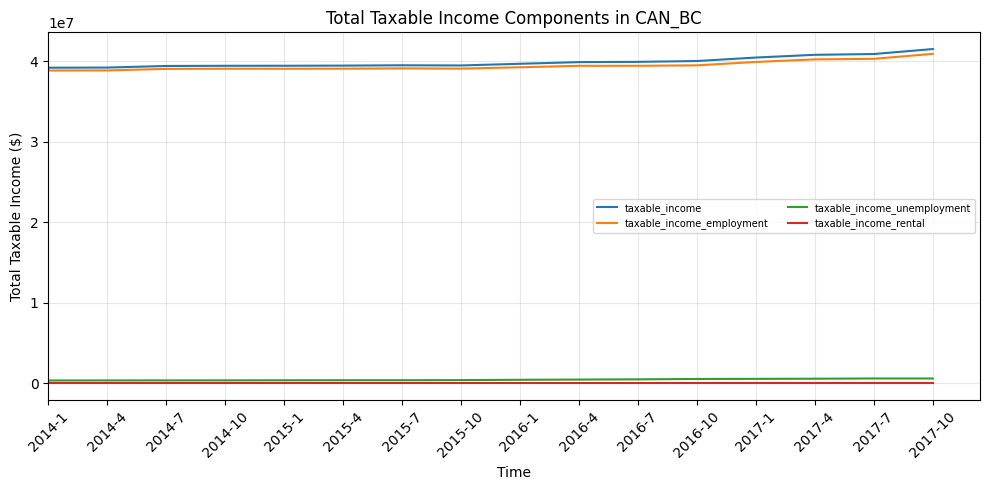

In [91]:
### plot ALL total taxable income streams over time

import matplotlib.pyplot as plt
import datetime

H5_FILE = OUTPUT_DIRECTORY / OUTPUT_FILENAME
PROVINCE_LABELS = {
    "CAN_AB": "Alberta",      "CAN_BC": "British Columbia", "CAN_MB": "Manitoba",
    "CAN_NB": "New Brunswick","CAN_NL": "Newfoundland",     "CAN_NS": "Nova Scotia",
    "CAN_ON": "Ontario",      "CAN_PE": "PEI",              "CAN_QC": "Quebec",
    "CAN_SK": "Saskatchewan",
}

# variables to plot
variable_str = []
variable_str.append("taxable_income")
variable_str.append("taxable_income_employment")
variable_str.append("taxable_income_unemployment")
variable_str.append("taxable_income_rental")

num_variables = len(variable_str)

for i in range(num_variables):
    print(variable_str[i])

path_str = []
data = []

fig, ax = plt.subplots(figsize=(10, 5))
with h5py.File(H5_FILE, "r") as f:
    # for region in regions:
    region = "CAN_BC"
    agent = "/individuals/"
    for i in range(num_variables):
        path_str = region + agent + variable_str[i]

        if path_str in f:
            data.append(f[path_str][()].astype(float)/1000)

        ax.plot(ts_time, np.sum(data[i], axis=1), 
            linestyle='-', 
            label=variable_str[i]
            )
    
ax.set_title(f"Total Taxable Income Components in {region}") 
ax.set_xlabel("Time")
ax.set_xlim(left=1)             # exclude initialization timestep
ax.tick_params("x", rotation=45)
# ax.set_xticks(ts_time[::4])   # control xtick frequency
ax.set_ylabel("Total Taxable Income ($)")

# ax.set_yscale('log')          # log plot toggle
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / f"taxable_income_trajectory_{datetime.date.today()}", dpi=120)
plt.show()
